#📌 Extracción

In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

## Normalizar las columnas anidadas

In [7]:

customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

## Unir todas las columnas

In [8]:
df_final = pd.concat(
    [df[["customerID", "Churn"]], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Revisar tipos de datos

In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [10]:
df_final["Charges.Total"] = pd.to_numeric(df_final["Charges.Total"], errors="coerce")

In [11]:
df_final["Charges.Total"].isnull().sum()

np.int64(11)

In [12]:
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [15]:
df_final = df_final.dropna(subset=["Charges.Total"])

In [16]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [17]:
#revisar valores nulos
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [18]:
#revisar registros duplicados
df_final.duplicated().sum()

np.int64(0)

In [20]:
#Revisar valores únicos en variables categóricas
print(df_final["Churn"].unique())
print(df_final["InternetService"].unique())
print(df_final["Contract"].unique())
print(df_final["PaymentMethod"].unique())

['No' 'Yes' '']
['DSL' 'Fiber optic' 'No']
['One year' 'Month-to-month' 'Two year']
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [38]:
import numpy as np

df_final["Churn"] = df_final["Churn"].astype(str).str.strip()
df_final["Churn"] = df_final["Churn"].replace("", np.nan)

df_final = df_final.dropna(subset=["Churn"])

df_final["Churn"].unique()
df_final["Churn"].value_counts()



,count
Churn,
No,5163
Yes,1869


Tras revisar el dataset se identificaron valores nulos en la variable Charges.Total, los cuales fueron eliminados. No se encontraron registros duplicados ni inconsistencias en las categorías. Por lo tanto, los datos se encuentran listos para la etapa de análisis exploratorio (EDA).

In [21]:
#Crear la columna Cuentas_Diarias
df_final["Cuentas_Diarias"] = df_final["Charges.Monthly"] / 30

In [22]:
df_final[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Con el objetivo de analizar el comportamiento del gasto de los clientes con mayor precisión, se creó la variable Cuentas_Diarias, la cual representa el costo promedio diario del servicio. Esta se obtuvo dividiendo la facturación mensual (Charges.Monthly) entre 30 días.

#📊 Carga y análisis

##Análisis Descriptivo

In [25]:
df_final.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.1629,32.395535,64.755423,2280.634213,2.158514
std,0.3693,24.558067,30.125739,2268.632997,1.004191
min,0.0000,1.000000,18.250000,18.800000,0.608333
25%,0.0000,9.000000,35.450000,400.225000,1.181667
50%,0.0000,29.000000,70.300000,1391.000000,2.343333
75%,0.0000,55.000000,89.900000,3785.300000,2.996667
max,1.0000,72.000000,118.750000,8684.800000,3.958333


El análisis descriptivo permite observar el comportamiento general de las variables numéricas. Se puede identificar el promedio de los cargos mensuales y totales, así como la dispersión de los datos mediante la desviación estándar. Estas métricas ayudan a comprender la variabilidad en el gasto de los clientes y sirven como base para el análisis exploratorio posterior.

##Distribución de evasión

In [52]:
#Ver distribución de churn
df_final["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [53]:
#Ver porcentaje de churn
df_final["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


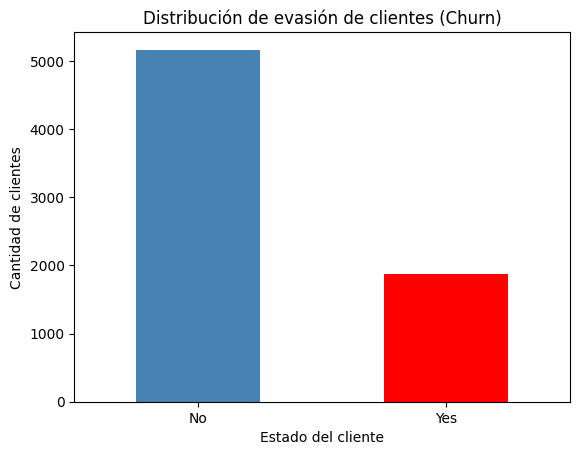

In [51]:
#Gráfico de distribución
import matplotlib.pyplot as plt

df_final["Churn"].value_counts().plot(
    kind="bar",
    color=["steelblue","red"]
)

plt.title("Distribución de evasión de clientes (Churn)")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=0)

plt.show()

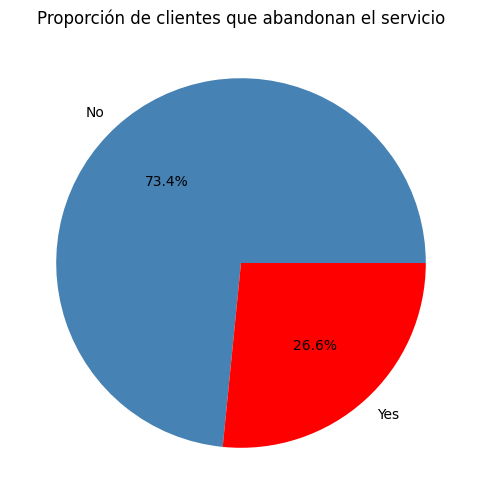

In [50]:
#gráfico circular
df_final["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["steelblue","red"],
    figsize=(6,6)
)

plt.title("Proporción de clientes que abandonan el servicio")
plt.ylabel("")

plt.show()

El análisis de la variable Churn muestra la proporción de clientes que permanecen en el servicio frente a aquellos que cancelaron su suscripción. Este análisis es fundamental para entender la magnitud del problema de evasión de clientes y sirve como punto de partida para identificar los factores que influyen en la cancelación del servicio.

##Recuento de evasión por variables categóricas

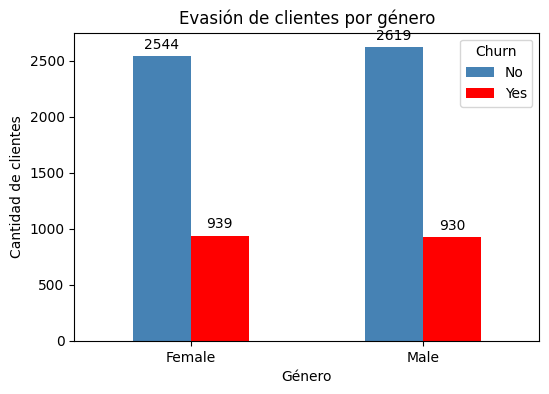

In [40]:
#Churn por género
tabla = pd.crosstab(df_final["gender"], df_final["Churn"])[["No","Yes"]]

ax = tabla.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))

plt.title("Evasión de clientes por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(title="Churn")
plt.show()

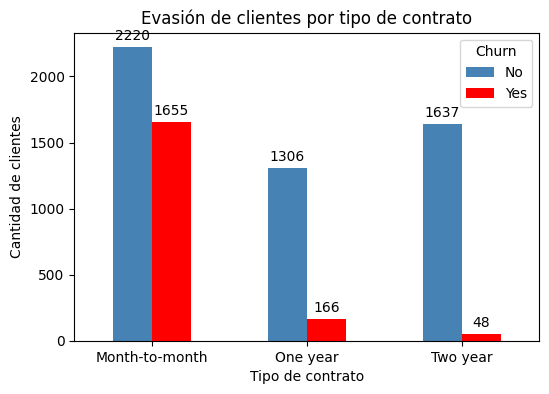

In [41]:
#Churn por tipo de contrato
tabla = pd.crosstab(df_final["Contract"], df_final["Churn"])[["No","Yes"]]

ax = tabla.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))

plt.title("Evasión de clientes por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(title="Churn")
plt.show()

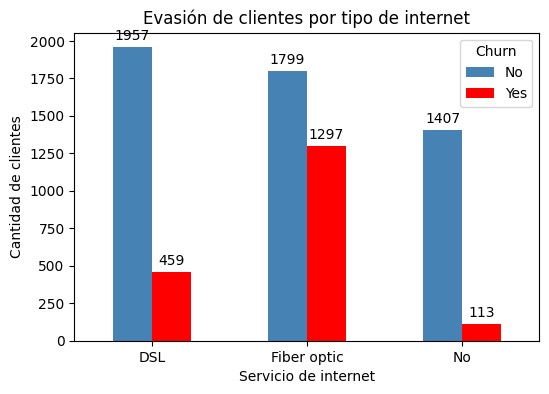

In [42]:
#Churn por servicio de internet
tabla = pd.crosstab(df_final["InternetService"], df_final["Churn"])[["No","Yes"]]

ax = tabla.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))

plt.title("Evasión de clientes por tipo de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(title="Churn")
plt.show()

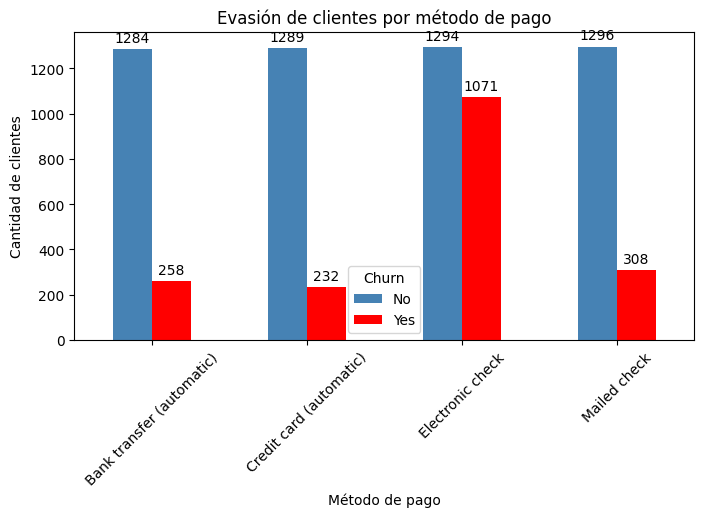

In [43]:
#Churn por método de pago
tabla = pd.crosstab(df_final["PaymentMethod"], df_final["Churn"])[["No","Yes"]]

ax = tabla.plot(kind="bar", color=["steelblue","red"], figsize=(8,4))

plt.title("Evasión de clientes por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(title="Churn")
plt.show()

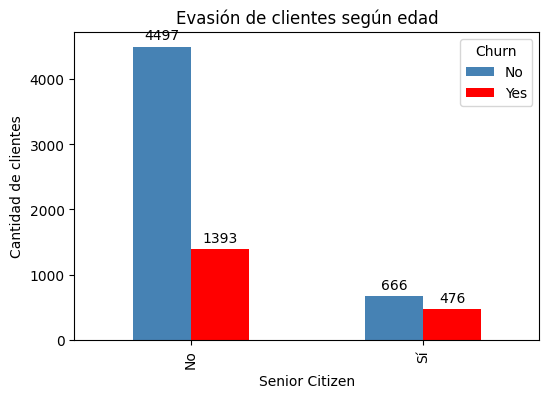

In [45]:
#Churn por Senior Citizen
tabla = pd.crosstab(df_final["SeniorCitizen"], df_final["Churn"])[["No","Yes"]]

ax = tabla.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))

plt.title("Evasión de clientes según edad")
plt.xlabel("Senior Citizen")
plt.ylabel("Cantidad de clientes")

plt.xticks([0,1], ["No","Sí"])

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(title="Churn")
plt.show()

##Conteo de evasión por variables numéricas

/tmp/ipykernel_300/3644012512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


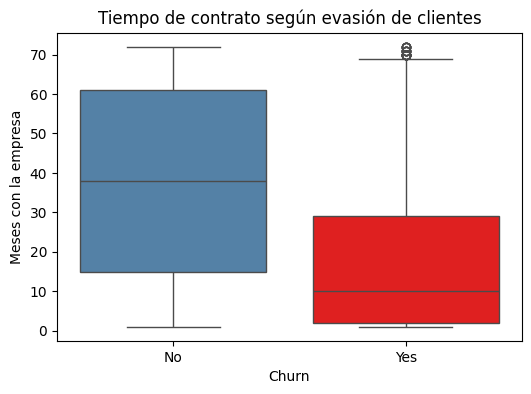

In [46]:
#Churn vs tiempo de contrato (tenure)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df_final,
    palette=["steelblue","red"]
)

plt.title("Tiempo de contrato según evasión de clientes")
plt.xlabel("Churn")
plt.ylabel("Meses con la empresa")

plt.show()

/tmp/ipykernel_300/3485274132.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


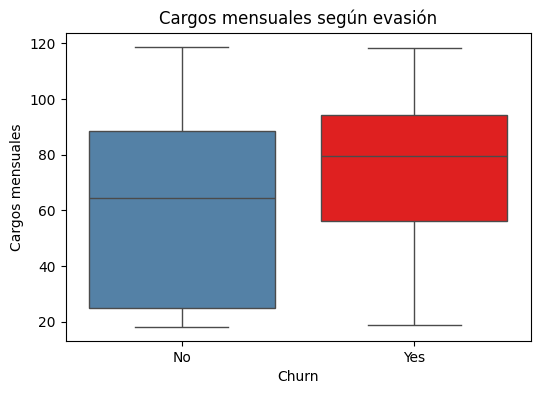

In [47]:
#Churn vs cargos mensuales
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="Charges.Monthly",
    data=df_final,
    palette=["steelblue","red"]
)

plt.title("Cargos mensuales según evasión")
plt.xlabel("Churn")
plt.ylabel("Cargos mensuales")

plt.show()

/tmp/ipykernel_300/2954922629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


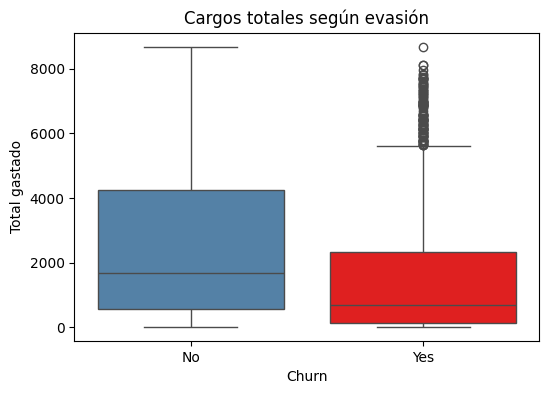

In [48]:
#Churn vs cargos totales
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="Charges.Total",
    data=df_final,
    palette=["steelblue","red"]
)

plt.title("Cargos totales según evasión")
plt.xlabel("Churn")
plt.ylabel("Total gastado")

plt.show()

/tmp/ipykernel_300/87408750.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


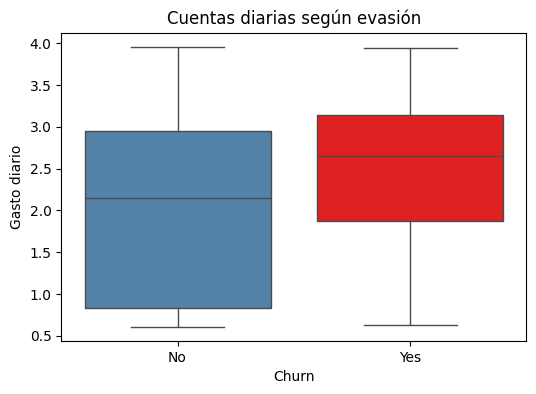

In [49]:
#Churn vs gasto diario
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="Cuentas_Diarias",
    data=df_final,
    palette=["steelblue","red"]
)

plt.title("Cuentas diarias según evasión")
plt.xlabel("Churn")
plt.ylabel("Gasto diario")

plt.show()

El análisis de las variables numéricas muestra que los clientes que cancelan el servicio suelen tener menor tiempo de permanencia en la empresa. Asimismo, se observa que los cargos mensuales y el gasto diario pueden influir en la probabilidad de evasión, lo que sugiere que el costo del servicio podría estar relacionado con la decisión de cancelar.

#📄Informe final

##Introducción


El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en Telecom X. La evasión de clientes representa un desafío importante para las empresas de telecomunicaciones, ya que implica la pérdida de ingresos y el aumento de costos asociados a la adquisición de nuevos clientes.

A través del análisis de los datos disponibles, se busca identificar patrones en el comportamiento de los clientes que cancelan el servicio. Para ello, se analizaron variables demográficas, características del servicio contratado, métodos de pago y variables relacionadas con los cargos mensuales y el tiempo de permanencia del cliente en la empresa.

Este análisis permitirá obtener información valiosa para proponer estrategias que ayuden a reducir la tasa de evasión de clientes.

##Limpieza y Tratamiento de Datos

Los datos fueron obtenidos desde una API en formato JSON. Debido a que el dataset contenía estructuras anidadas, fue necesario realizar un proceso de transformación para convertir la información en un DataFrame estructurado.

Durante esta etapa se realizaron los siguientes pasos:

Importación de los datos utilizando la librería Pandas.

Normalización de las columnas anidadas (customer, phone, internet, account) para convertirlas en variables independientes.

Unificación de los datos en un único DataFrame.

Conversión de variables numéricas como Charges.Total al tipo de dato adecuado.

Verificación de valores nulos, duplicados y posibles inconsistencias en variables categóricas.

Creación de la variable Cuentas_Diarias, calculada a partir de los cargos mensuales.

Después de estos procesos, el dataset quedó limpio y listo para el análisis exploratorio.

##Análisis Exploratorio de Datos

Se realizaron diversos análisis para identificar patrones asociados a la evasión de clientes.

###Distribución de evasión

El análisis de la variable Churn permitió observar la proporción de clientes que permanecen en la empresa frente a aquellos que cancelan el servicio. Este análisis proporciona una visión general del problema de evasión.



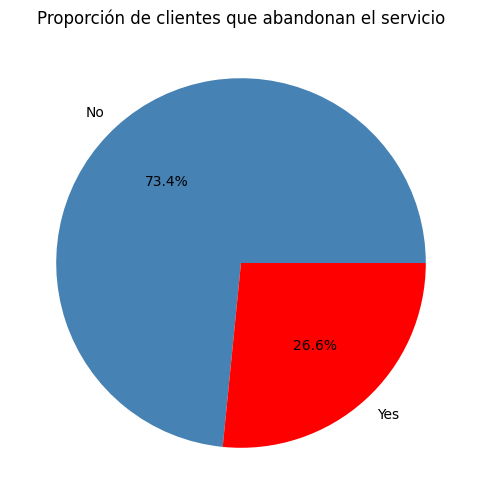

In [54]:
#gráfico circular
df_final["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["steelblue","red"],
    figsize=(6,6)
)

plt.title("Proporción de clientes que abandonan el servicio")
plt.ylabel("")

plt.show()

###Evasión por variables categóricas

Se exploró la evasión de clientes según diferentes variables categóricas como:

género

tipo de contrato

tipo de servicio de internet

método de pago

clientes senior

Los resultados muestran que los clientes con contratos Month-to-month presentan una mayor tendencia a cancelar el servicio en comparación con aquellos con contratos de mayor duración.

Asimismo, se observa que ciertos métodos de pago y tipos de servicio de internet pueden estar asociados con mayores tasas de evasión.



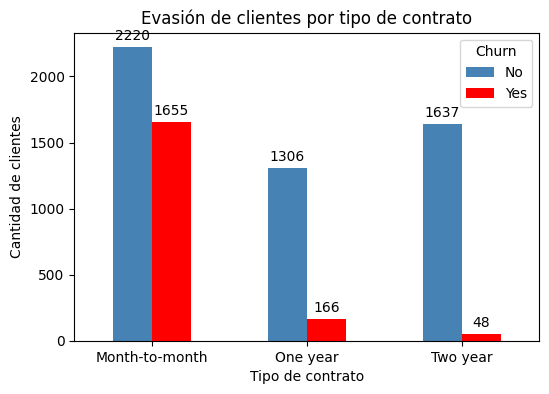

In [55]:
#Churn por tipo de contrato
tabla = pd.crosstab(df_final["Contract"], df_final["Churn"])[["No","Yes"]]

ax = tabla.plot(kind="bar", color=["steelblue","red"], figsize=(6,4))

plt.title("Evasión de clientes por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(title="Churn")
plt.show()

###Evasión según variables numéricas

También se analizaron variables numéricas como:

tiempo de permanencia del cliente (tenure)

cargos mensuales (Charges.Monthly)

cargos totales (Charges.Total)

gasto diario (Cuentas_Diarias)

Los resultados sugieren que los clientes con menor tiempo de permanencia tienen mayor probabilidad de cancelar el servicio. Además, niveles más altos de cargos mensuales pueden estar relacionados con mayores tasas de evasión.

/tmp/ipykernel_300/3644012512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


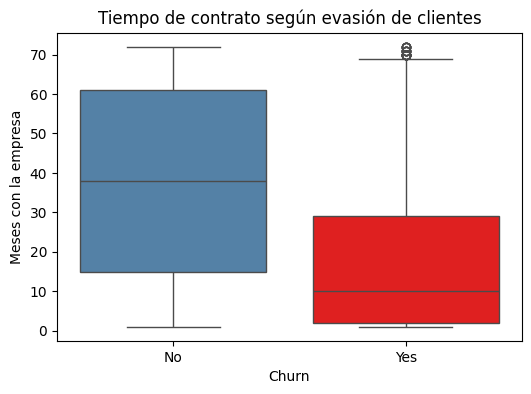

In [56]:
#Churn vs tiempo de contrato (tenure)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df_final,
    palette=["steelblue","red"]
)

plt.title("Tiempo de contrato según evasión de clientes")
plt.xlabel("Churn")
plt.ylabel("Meses con la empresa")

plt.show()

##Conclusiones e Insights

A partir del análisis exploratorio realizado sobre las variables categóricas y numéricas, se identificaron varios patrones relevantes que ayudan a explicar el comportamiento de evasión de los clientes.

###Contrato del cliente

Uno de los factores más influyentes en la evasión es el tipo de contrato. Los clientes con contratos Month-to-month presentan una tasa de cancelación significativamente mayor en comparación con aquellos que poseen contratos de uno o dos años.

Esto sugiere que los clientes con compromisos de corto plazo tienen mayor facilidad para cancelar el servicio, mientras que los contratos de mayor duración ayudan a mejorar la retención.

###Tiempo de permanencia del cliente

El análisis de la variable tenure muestra que los clientes que abandonan el servicio suelen tener menos tiempo con la empresa. Esto indica que la evasión ocurre principalmente en las primeras etapas de la relación con el cliente.

Este patrón sugiere que los primeros meses de servicio son críticos para la fidelización.

###Cargos mensuales

Los clientes con cargos mensuales más altos muestran una mayor tendencia a cancelar el servicio. Esto podría indicar que algunos clientes perciben el costo del servicio como elevado en relación con el valor recibido.

Por lo tanto, el precio o la percepción de valor puede ser un factor importante en la decisión de cancelar.

###Tipo de servicio de internet

El análisis también muestra que los clientes con servicio de fibra óptica presentan niveles más altos de evasión en comparación con otros tipos de conexión. Esto puede estar relacionado con expectativas más altas de calidad del servicio o con la disponibilidad de alternativas competitivas en el mercado.

###Método de pago

Se observa que los clientes que utilizan Electronic Check presentan mayores tasas de evasión en comparación con otros métodos de pago automáticos como tarjetas de crédito o transferencias bancarias.

Esto podría indicar que los métodos de pago automáticos están asociados con una mayor permanencia del cliente.

###Factores demográficos

El análisis por género muestra que la evasión está relativamente equilibrada entre hombres y mujeres, lo que indica que el género no parece ser un factor determinante en la cancelación del servicio.

##Recomendaciones

Con base en los insights obtenidos, se sugieren las siguientes acciones para reducir la evasión de clientes:

###Incentivar contratos de largo plazo

Promover planes de uno o dos años mediante descuentos, beneficios adicionales o promociones especiales para reducir la probabilidad de cancelación.

###Mejorar la experiencia del cliente en los primeros meses

Dado que la evasión ocurre principalmente en los primeros meses, es recomendable implementar estrategias de onboarding y acompañamiento para nuevos clientes, asegurando una buena experiencia inicial.

###Revisar la estructura de precios

Analizar los planes con cargos mensuales más elevados para evaluar si el precio se ajusta al valor percibido por el cliente.

###Promover métodos de pago automáticos

Fomentar el uso de tarjetas de crédito o transferencias automáticas, ya que estos métodos parecen estar asociados con menor evasión.

###Analizar la experiencia del servicio de fibra óptica

Dado que los clientes con este servicio presentan mayor evasión, sería importante evaluar aspectos como calidad del servicio, soporte técnico y satisfacción del cliente.